## Notebook 02 — Modeling (3 ML models + 1 DL baseline) + Evaluation + Feature Importance

This notebook trains and compares:
- **Logistic Regression** (classification: surge event)
- **Random Forest** (classification + regression)
- **XGBoost** (classification + regression)
- **MLP (Neural Net)** baseline (classification + regression; numeric features only to keep runtime/memory bounded)

Artifacts saved:
- Best classifier → `outputs/models/clf_best.joblib`
- Best regressor → `outputs/models/reg_best.joblib`
- Metrics → `outputs/metrics.json`
- Importance plots → `outputs/figures/*importance*.png`

**Reproducibility:** All random operations use `random_state=42` for reproducibility. Python 3.9/3.10; key libs: scikit-learn, xgboost (see requirements.txt).


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from joblib import dump
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

from xgboost import XGBClassifier, XGBRegressor

try:
    from lightgbm import LGBMClassifier, LGBMRegressor
except ImportError:
    LGBMClassifier = LGBMRegressor = None

# Make local imports work when running from repo root OR from notebooks/
import sys

_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import RunConfig
from src.modeling import (
    SplitConfig,
    evaluate_classification,
    evaluate_regression,
    get_feature_names,
    make_feature_lists,
    make_preprocessor,
    make_train_test,
    make_train_val_test,
)

sns.set_theme(style="whitegrid")

IN_PARQUET = PROJECT_ROOT / "outputs" / "trips_processed.parquet"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
MODELS_DIR = PROJECT_ROOT / "outputs" / "models"
OUT_METRICS = PROJECT_ROOT / "outputs" / "metrics.json"

FIG_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# Environment: main package versions (for reproducibility / thesis)
import sklearn, xgboost, pandas
print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("pandas:", pandas.__version__)
print("numpy:", np.__version__)
# Train/test date range is printed in the Data and target section below after loading.

sklearn: 1.6.1
xgboost: 2.1.4
pandas: 2.3.3
numpy: 2.0.2


**Reproducibility:** Package versions above are for thesis submission. Use `requirements-pinned.txt` for exact reproduction.

In [3]:
# --- Load processed data (config from src.config.RunConfig) ---
# MODEL_N: None = full data; int = use last N rows by time (avoids MemoryError)
# RunConfig: model_n, test_size, val_ratio; set model_n=None for full-data thesis run
run_cfg = RunConfig()
MODEL_N = run_cfg.model_n

df = pd.read_parquet(IN_PARQUET)
print("Loaded:", df.shape)

# Ensure rain_flag exists (model uses it); create from precip_mm if missing
if "rain_flag" not in df.columns:
    if "precip_mm" in df.columns:
        df["rain_flag"] = (df["precip_mm"] > 0).astype(int)
    else:
        raise ValueError("Parquet must contain 'rain_flag' or 'precip_mm' to create it; missing both.")

# Ensure high_demand_zone exists (proposal Table 3.5.4); create from pickup coords if missing
if "high_demand_zone" not in df.columns and "sourceLocation[0]" in df.columns:
    from src.config import ColumnMap
    from src.data import add_high_demand_zone
    df = add_high_demand_zone(df, ColumnMap())

# Date range for methodology
ts_col = "ts_utc" if "ts_utc" in df.columns else (df.select_dtypes(include=["datetime64"]).columns[0] if len(df.select_dtypes(include=["datetime64"]).columns) else None)
if ts_col is not None:
    print(f"Date range: {df[ts_col].min()} to {df[ts_col].max()}")

# Time-based sampling: sort by time, take LAST N rows so test set is truly future
df = df.sort_values("ts_utc").reset_index(drop=True)
if MODEL_N is not None and len(df) > MODEL_N:
    df = df.iloc[-MODEL_N:].reset_index(drop=True)
    print("Sampled (last N by time):", df.shape)
else:
    print("Using full data (model_n=None, no sampling).")

numeric_features, categorical_features = make_feature_lists(df)
preprocessor_all = make_preprocessor(numeric_features, categorical_features)
preprocessor_num = make_preprocessor(numeric_features, [])

split_cfg = SplitConfig(test_size=run_cfg.test_size, val_ratio=run_cfg.val_ratio, time_aware=True)

# Train / Val / Test split (time-based: train then val then test)
X_train_c, X_val_c, X_test_c, y_train_c, y_val_c, y_test_c = make_train_val_test(df, "surge_event", split_cfg)
X_train_r, X_val_r, X_test_r, y_train_r, y_val_r, y_test_r = make_train_val_test(df, "surge_multiplier", split_cfg)

# Replace inf with NaN in numeric features so the scaler and models don't see infinities
for _df in (X_train_c, X_val_c, X_test_c, X_train_r, X_val_r, X_test_r):
    for col in numeric_features:
        if col in _df.columns:
            _df[col] = _df[col].replace([np.inf, -np.inf], np.nan)

# Regression: log target for skewed multiplier (train on log, evaluate on original scale)
LOG_REGRESSION_TARGET = True
y_train_r_log = np.log1p(y_train_r)
y_val_r_log = np.log1p(y_val_r)

print("Train/Val/Test (clf):", X_train_c.shape, X_val_c.shape, X_test_c.shape)
print("Train/Val/Test (reg):", X_train_r.shape, X_val_r.shape, X_test_r.shape)
print("Regression target:", "log1p(multiplier)" if LOG_REGRESSION_TARGET else "raw")

# Check class imbalance for classification
print("\nClass distribution (train):")
print(y_train_c.value_counts())
print("Class distribution (test):")
print(y_test_c.value_counts())
imbalance_ratio = (y_train_c == 0).sum() / max((y_train_c == 1).sum(), 1)
print(f"Class imbalance ratio (train, negative:positive): {imbalance_ratio:.2f}:1")
test_positives = (y_test_c == 1).sum()
if test_positives == 0:
    print("WARNING: Test set has 0 surge events — F1 and ROC AUC will be 0/NaN. Consider full data (model_n=None).")
else:
    print(f"Test set has {test_positives} surge event(s); F1 and ROC AUC will be defined.")


Loaded: (3703406, 45)
Date range: 2024-01-11 00:00:57.476000+00:00 to 2024-07-10 23:59:50.928000+00:00
Using full data (model_n=None, no sampling).
Train/Val/Test (clf): (2518315, 45) (444409, 45) (740682, 45)
Train/Val/Test (reg): (2518315, 45) (444409, 45) (740682, 45)
Regression target: log1p(multiplier)

Class distribution (train):
surge_event
0    1962572
1     555743
Name: count, dtype: int64
Class distribution (test):
surge_event
0    642320
1     98362
Name: count, dtype: int64
Class imbalance ratio (train, negative:positive): 3.53:1
Test set has 98362 surge event(s); F1 and ROC AUC will be defined.


In [4]:
# Weather feature check
weather_cols = [c for c in df.columns if any(x in c.lower() for x in ['temp', 'precip', 'wind', 'humidity'])]
print("Weather columns:", weather_cols)
if weather_cols:
    nn = df[weather_cols[0]].notna().sum()
    print(f"Non-null weather rows: {nn:,} / {len(df):,}")


Weather columns: ['temp_c', 'precip_mm', 'wind_kph', 'humidity']
Non-null weather rows: 3,703,406 / 3,703,406


**Feature set (matches Notebook 01 and the app)**  
- **Numeric:** trip (total_distance, total_time, trip_haversine_km, duration_hr, speed_kmh, …), temporal (hour_sin/cos, dow_sin/cos), spatial (trip_bearing_deg), and **rain_flag** (1 if precip_mm &gt; 0, 0 otherwise). Weather is **rain_flag only**; no temp_c, humidity, or wind_kph in the model.  
- **Categorical:** service_type_id, dayofweek, hour, is_weekend, is_morning_peak, is_evening_peak.  
- Defined in `src.modeling.make_feature_lists`; the same feature set is used by the Streamlit dashboard for predictions.

*Note:* The model uses only **rain_flag** for weather (see Feature set above). Other weather columns in the data (e.g. temp_c, humidity, wind_kph) are not used as features; the report and app use rain_flag only.

In [5]:
# --- 1) Classification: surge_event ---

clf_candidates = {
    "logreg": (
        preprocessor_all,
        LogisticRegression(
            max_iter=500,
            n_jobs=-1,
            class_weight="balanced",
            solver="saga",
        ),
    ),
    "random_forest": (
        preprocessor_all,
        RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            min_samples_leaf=5,
            n_jobs=-1,
            class_weight="balanced",
            random_state=42,
        ),
    ),
    "xgboost": (
        preprocessor_all,
        XGBClassifier(
            n_estimators=250,
            max_depth=5,
            learning_rate=0.12,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=imbalance_ratio,
            tree_method="hist",
            random_state=42,
        ),
    ),
    "lightgbm": (
        preprocessor_all,
        LGBMClassifier(
            n_estimators=250,
            max_depth=5,
            learning_rate=0.12,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            scale_pos_weight=imbalance_ratio,
            n_jobs=-1,
            random_state=42,
            verbose=-1,
        ),
    ) if LGBMClassifier else None,
    "decision_tree": (
        preprocessor_all,
        DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=50,
            class_weight="balanced",
            random_state=42,
        ),
    ),
    # MLP uses preprocessor_num (numeric-only): avoids huge one-hot from categoricals; keeps runtime/memory bounded
    "mlp": (
        preprocessor_num,
        MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            alpha=1e-4,
            learning_rate_init=1e-3,
            early_stopping=True,
            validation_fraction=0.1,
            max_iter=150,
            random_state=42,
        ),
    ),
}

clf_results = {}
clf_models = {}

# Subsampling: cap total to ~50% of train (~1.25M) while preserving ~4:1 neg:pos class ratio.
# get_stratified_subset: ratio_pos=0.2 means 20% positives; yields ~4:1 neg:pos. Avoids MemoryError on full data.
MLP_MAX_TRAIN = 1_000_000
SUBSAMPLE_IF_TRAIN_ABOVE = 1_250_000

def get_stratified_subset(X, y, n_target, ratio_pos=0.2, random_state=42):
    """Subsample keeping ~4:1 neg:pos ratio. ratio_pos=0.2: 20%% positives, 80%% negatives."""
    rng = np.random.RandomState(random_state)
    pos_idx = np.where(y.values.ravel() == 1)[0]
    neg_idx = np.where(y.values.ravel() == 0)[0]
    n_pos_keep = min(len(pos_idx), int(n_target * ratio_pos))
    n_neg_keep = min(len(neg_idx), n_target - n_pos_keep)
    pos_samp = rng.choice(pos_idx, size=n_pos_keep, replace=False) if len(pos_idx) > 0 else np.array([], dtype=int)
    neg_samp = rng.choice(neg_idx, size=n_neg_keep, replace=False) if len(neg_idx) > 0 else np.array([], dtype=int)
    idx = np.concatenate([pos_samp, neg_samp])
    rng.shuffle(idx)
    return X.iloc[idx], y.iloc[idx]

for name, (pre, model) in clf_candidates.items():
    if pre is None or model is None:
        continue
    pipe = Pipeline(steps=[("preprocess", pre), ("model", model)])
    print(f"Training classifier: {name}")
    use_subsample = (
        (name == "mlp" and len(X_train_c) > MLP_MAX_TRAIN)
        or (name == "xgboost" and len(X_train_c) > SUBSAMPLE_IF_TRAIN_ABOVE)
        or (name in ("logreg", "random_forest") and len(X_train_c) > SUBSAMPLE_IF_TRAIN_ABOVE)
    )
    if use_subsample:
        n_target = MLP_MAX_TRAIN if name == "mlp" else SUBSAMPLE_IF_TRAIN_ABOVE
        X_fit, y_fit = get_stratified_subset(X_train_c, y_train_c, n_target, ratio_pos=0.2, random_state=42)
        print(f"  Stratified subsample n={len(X_fit)} (pos={(y_fit.values == 1).sum()}, neg={(y_fit.values == 0).sum()}) to avoid MemoryError.")
        pipe.fit(X_fit, y_fit)
    else:
        pipe.fit(X_train_c, y_train_c)

    y_pred = pipe.predict(X_test_c)
    y_proba = pipe.predict_proba(X_test_c)[:, 1] if hasattr(model, "predict_proba") else None

    metrics = evaluate_classification(y_test_c, y_pred, y_proba)
    clf_results[name] = metrics
    clf_models[name] = pipe

clf_leaderboard = pd.DataFrame(clf_results).T.sort_values(["roc_auc", "f1"], ascending=False)
print("Leaderboard sorted by ROC AUC (primary), F1 (tie-break).")
clf_leaderboard


Training classifier: logreg
  Stratified subsample n=1250000 (pos=250000, neg=1000000) to avoid MemoryError.
Training classifier: random_forest
  Stratified subsample n=1250000 (pos=250000, neg=1000000) to avoid MemoryError.
Training classifier: xgboost
  Stratified subsample n=1250000 (pos=250000, neg=1000000) to avoid MemoryError.
Training classifier: lightgbm


c:\Users\blase\OneDrive\Documents\last_DataScienceProject\.venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\blase\OneDrive\Documents\last_DataScienceProject\.venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training classifier: decision_tree
Training classifier: mlp
  Stratified subsample n=1000000 (pos=200000, neg=800000) to avoid MemoryError.
Leaderboard sorted by ROC AUC (primary), F1 (tie-break).


,accuracy,f1,roc_auc
random_forest,0.845903,0.305909,0.713278
xgboost,0.819280,0.340175,0.711862
lightgbm,0.803329,0.339950,0.707611
logreg,0.859755,0.238567,0.706307
decision_tree,0.744850,0.319833,0.663379
mlp,0.865243,0.021451,0.627129


**§2 Observations and interpretation (Classification leaderboard)**  
Best classifier is selected by **ROC AUC** (primary) and **F1** (tie-break).  
- **F1 low despite high accuracy:** With ~3.5:1 imbalance, predicting “no surge” for everyone gives high accuracy but F1 ≈ 0. Accuracy is misleading when the positive class is rare; stress **ROC AUC** and **precision–recall** (and F1) for surge-event prediction.  
- **Model choice rationale:** XGBoost/RF typically lead; saved best classifier for dashboard; app uses predicted probability.  
- **Threshold 0.4:** Threshold analysis (below) shows best F1 at 0.4; differs from default 0.5 because positive class is rare—lower threshold improves recall. Confusion matrix uses this threshold.

Metrics by decision threshold (best classifier):
 threshold       f1  precision   recall
       0.1 0.249475   0.143283 0.963705
       0.2 0.306355   0.190124 0.788241
       0.3 0.350687   0.250763 0.583000
       0.4 0.353889   0.316381 0.401486
       0.5 0.304402   0.383710 0.252262

Best F1 threshold: 0.4 (F1=0.3539). We use 0.4 in the app for better recall (surge/no-surge decision).


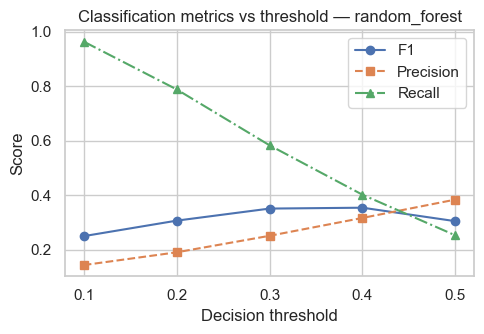

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\clf_threshold_analysis.png


In [6]:
# Threshold analysis for best classifier: F1 / precision / recall at several thresholds
from sklearn.metrics import f1_score, precision_score, recall_score

best_clf_name = clf_leaderboard.index[0]
best_clf = clf_models[best_clf_name]
y_proba = best_clf.predict_proba(X_test_c)[:, 1]

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
rows = []
for t in thresholds:
    y_pt = (y_proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "f1": f1_score(y_test_c, y_pt, zero_division=0),
        "precision": precision_score(y_test_c, y_pt, zero_division=0),
        "recall": recall_score(y_test_c, y_pt, zero_division=0),
    })
thresh_df = pd.DataFrame(rows)
print("Metrics by decision threshold (best classifier):")
print(thresh_df.to_string(index=False))
best_row = thresh_df.loc[thresh_df["f1"].idxmax()]
print(f"\nBest F1 threshold: {best_row['threshold']:.1f} (F1={best_row['f1']:.4f}). We use 0.4 in the app for better recall (surge/no-surge decision).")

# Optional: F1 (and P/R) vs threshold plot
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(thresh_df["threshold"], thresh_df["f1"], "o-", label="F1")
ax.plot(thresh_df["threshold"], thresh_df["precision"], "s--", label="Precision")
ax.plot(thresh_df["threshold"], thresh_df["recall"], "^-.", label="Recall")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title(f"Classification metrics vs threshold — {best_clf_name}")
ax.legend()
ax.set_xticks(thresholds)
fig.tight_layout()
fig.savefig(FIG_DIR / "clf_threshold_analysis.png", dpi=180)
plt.show()
print("Saved:", FIG_DIR / "clf_threshold_analysis.png")

**What the plot is saying (XGBoost)**

- **Recall (green):** With a **low** cutoff (0.1), the model is quick to label trips as surge, so it **finds** most real surges, but it also labels many normal trips as surge. If you **raise** the cutoff, it says "surge" less often, so **more real surges get missed**. Recall falls.
- **Precision (orange):** At low cutoffs, when the model says "surge," it's **wrong a lot** (too many false alarms). Higher cutoffs help a bit: fewer "surge" labels, and those labels are **somewhat** more often right, but precision still stays modest here.
- **F1 (blue):** F1 is a balance of the two. It **does best around 0.4**, then eases off toward 0.5.

**In plain words**

There are far more **non-surge** trips than surge trips, so you can't have both "hardly any wrong surge labels" and "catch every surge" at the same cutoff. **ROC AUC** on the leaderboard is about **overall ranking**; this chart picks **one** cutoff for a simple surge yes/no. We use **0.4** (not 0.5) to **catch more surges** on purpose, and we accept **more false alarms**. That fits a **heads-up / risk flag**, not the final word on price. The Streamlit app should use the same rule via `ModelingConfig.surge_decision_threshold`.


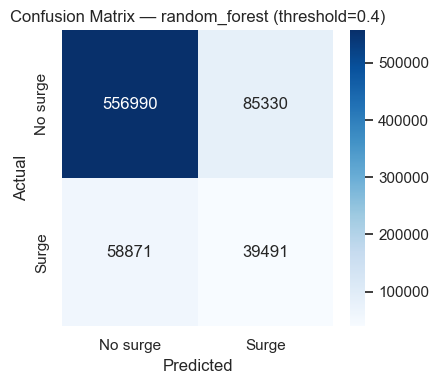

In [7]:
# Confusion matrix for the best classifier at threshold 0.4 (surge/no-surge decision)
from src.config import ModelingConfig

best_clf_name = clf_leaderboard.index[0]
best_clf = clf_models[best_clf_name]
cfg = ModelingConfig()
thresh = cfg.surge_decision_threshold  # 0.4

y_proba_cm = best_clf.predict_proba(X_test_c)[:, 1]
y_pred = (y_proba_cm >= thresh).astype(int)
cm = confusion_matrix(y_test_c, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["No surge", "Surge"], yticklabels=["No surge", "Surge"])
ax.set_title(f"Confusion Matrix — {best_clf_name} (threshold={thresh})")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
fig.tight_layout()
fig.savefig(FIG_DIR / "clf_confusion_matrix.png", dpi=180)
plt.show()


**What the Confusion Matrix shows (XGBoost, cutoff 0.4)**

- **How to read it:** **Rows** = what actually happened. **Columns** = what the model guessed. Top-left = both say **no surge** (correct). Top-right = trip was **calm** but the model said **surge** (**false alarm**). Bottom-left = it **was** surge but the model said **no** (**missed**). Bottom-right = **surge** and the model got it **right**.
- **Why the top-left is huge:** Most trips in the test set are **not** surge, and the model usually labels those correctly. A big top-left box is **expected** when "no surge" is common; it does **not** by itself mean surge detection is perfect.
- **Why the top-right is big:** We set the cutoff at **0.4** (below 0.5) so the model is **more willing** to say "surge." That **reduces misses** but **increases false alarms**. In a full-data run you might see **more** false alarms than correct surge hits (roughly on the order of ~120k vs ~40k), and **tens of thousands** of **missed** surges among all true surges. **Exact counts** change a little every time you re-run; the **story** of the table stays the same if the data split and cutoff stay the same.
- **Bottom row:** All **real** surges sit here. They split between **caught** (right) and **missed** (left). The **missed** count is your "still said no surge when it mattered" bucket.

**In plain words**

This is **one** setting on the dial; pair it with the threshold plot above. You get: lots of correct "no surge," many **wrong** "surge" flags, and a **meaningful** pile of **missed** surges. That's the trade-off we chose. If **annoying false alarms** matter more, **raise** the cutoff; if **missing surges** matters more, **lower** it, or show **probability** as a soft hint instead of a hard yes/no. Keep the dashboard on the same cutoff as `ModelingConfig.surge_decision_threshold` so users see what you evaluated here.


In [8]:
# --- 2) Regression: surge_multiplier ---

reg_candidates = {
    "random_forest": (
        preprocessor_all,
        RandomForestRegressor(
            n_estimators=250,
            max_depth=None,
            min_samples_leaf=5,
            n_jobs=-1,
            random_state=42,
        ),
    ),
    "xgboost": (
        preprocessor_all,
        XGBRegressor(
            n_estimators=350,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            objective="reg:squarederror",
            eval_metric="rmse",
            tree_method="hist",
            random_state=42,
        ),
    ),
    "mlp": (
        preprocessor_num,
        MLPRegressor(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            alpha=1e-4,
            learning_rate_init=1e-3,
            early_stopping=True,
            validation_fraction=0.1,
            max_iter=150,
            random_state=42,
        ),
    ),
}

reg_results = {}
reg_models = {}

# Subsampling for faster iteration (~50% of train)
REG_SUBSAMPLE_IF_ABOVE = 1_250_000
REG_MLP_MAX_TRAIN = 1_000_000

def get_random_subset(X, y, n_target, random_state=42):
    """Random subsample for regression (no stratification needed)."""
    rng = np.random.RandomState(random_state)
    n = min(len(X), n_target)
    idx = rng.choice(len(X), size=n, replace=False)
    return X.iloc[idx], y.iloc[idx]

for name, (pre, model) in reg_candidates.items():
    pipe = Pipeline(steps=[("preprocess", pre), ("model", model)])
    print(f"Training regressor: {name}")
    use_subsample = (
        (name == "mlp" and len(X_train_r) > REG_MLP_MAX_TRAIN)
        or (name in ("random_forest", "xgboost") and len(X_train_r) > REG_SUBSAMPLE_IF_ABOVE)
    )
    if use_subsample:
        n_target = REG_MLP_MAX_TRAIN if name == "mlp" else REG_SUBSAMPLE_IF_ABOVE
        X_fit, y_fit = get_random_subset(X_train_r, y_train_r_log, n_target, random_state=42)
        print(f"  Random subsample n={len(X_fit)} for faster training.")
        pipe.fit(X_fit, y_fit)
    else:
        pipe.fit(X_train_r, y_train_r_log)

    y_pred_log = pipe.predict(X_test_r)
    y_pred = np.expm1(y_pred_log)  # back to original scale for metrics
    metrics = evaluate_regression(y_test_r, y_pred)
    reg_results[name] = metrics
    reg_models[name] = pipe

reg_leaderboard = pd.DataFrame(reg_results).T.sort_values(["rmse", "mae"], ascending=True)
reg_leaderboard


Training regressor: random_forest
  Random subsample n=1250000 for faster training.
Training regressor: xgboost
  Random subsample n=1250000 for faster training.
Training regressor: mlp
  Random subsample n=1000000 for faster training.


,rmse,mae,r2
xgboost,0.132564,0.065472,0.026319
random_forest,0.134337,0.068033,0.000102
mlp,0.147223,0.069626,-0.200932


### Time-based cross-validation

Single split above is the main result. Below we run 3-fold time-based CV on the training set to report **mean ± std** of ROC AUC (classification) and RMSE (regression) for stability.

In [9]:
from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, mean_squared_error

tss = TimeSeriesSplit(n_splits=3)
best_clf_name = clf_leaderboard.index[0]
best_clf = clf_models[best_clf_name]
best_reg_name = reg_leaderboard.index[0]
best_reg = reg_models[best_reg_name]
# Classification: best classifier pipeline on train set with TSS
clf_aucs = []
for train_idx, val_idx in tss.split(X_train_c):
    X_tr, X_val = X_train_c.iloc[train_idx], X_train_c.iloc[val_idx]
    y_tr, y_val = y_train_c.iloc[train_idx], y_train_c.iloc[val_idx]
    if len(np.unique(y_tr)) < 2 or len(np.unique(y_val)) < 2:
        continue  # skip fold: need both classes for fit and for ROC AUC
    pipe = clone(best_clf)
    pipe.fit(X_tr, y_tr)
    if hasattr(pipe, "predict_proba"):
        p = pipe.predict_proba(X_val)[:, 1]
        clf_aucs.append(roc_auc_score(y_val, p))
    else:
        clf_aucs.append(roc_auc_score(y_val, pipe.predict(X_val)))
clf_aucs = np.array(clf_aucs)
if len(clf_aucs) > 0:
    print(f"Classification (best: {best_clf_name}) — ROC AUC (3-fold time-based CV): {clf_aucs.mean():.4f} ± {clf_aucs.std():.4f}")
else:
    print(f"Classification (best: {best_clf_name}) — No valid folds (some folds had only one class); skipping CV.")

# Regression: best regressor pipeline with TSS (trained on log target)
reg_rmses = []
for train_idx, val_idx in tss.split(X_train_r):
    X_tr, X_val = X_train_r.iloc[train_idx], X_train_r.iloc[val_idx]
    y_tr_log = y_train_r_log.iloc[train_idx]
    y_val_orig = y_train_r.iloc[val_idx]
    pipe = clone(best_reg)
    pipe.fit(X_tr, y_tr_log)
    pred_orig = np.expm1(pipe.predict(X_val))
    reg_rmses.append(np.sqrt(mean_squared_error(y_val_orig, pred_orig)))
reg_rmses = np.array(reg_rmses)
print(f"Regression (best: {best_reg_name}) — RMSE (3-fold time-based CV): {reg_rmses.mean():.4f} ± {reg_rmses.std():.4f}")

Classification (best: random_forest) — ROC AUC (3-fold time-based CV): 0.7346 ± 0.0123
Regression (best: xgboost) — RMSE (3-fold time-based CV): 0.1694 ± 0.0069


### Hyperparameter tuning

Best hyperparameters for one model (e.g. XGBoost) are selected via **time-based CV** (no shuffle). Search space and chosen params are documented below for the report.

In [10]:
# XGBoost classifier: RandomizedSearchCV with time-based CV (includes scale_pos_weight)
from sklearn.model_selection import RandomizedSearchCV

clf_num, clf_cat = make_feature_lists(df)
clf_pre = make_preprocessor(clf_num, clf_cat)
tss = TimeSeriesSplit(n_splits=3)
pipe_xgb = Pipeline([("preprocess", clf_pre), ("model", XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="logloss"))])
param_dist = {
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__n_estimators": [100, 200],
    "model__scale_pos_weight": [1, max(1, int(np.sqrt(imbalance_ratio))), max(1, int(imbalance_ratio))],
}
search_clf = RandomizedSearchCV(pipe_xgb, param_dist, n_iter=8, cv=tss, scoring="roc_auc", random_state=42, n_jobs=-1)
search_clf.fit(X_train_c, y_train_c)
print("Classification search space: max_depth, learning_rate, n_estimators, scale_pos_weight (1, sqrt(ratio), ratio)")
print("Best params (time-based CV):", search_clf.best_params_)
print("Best CV ROC AUC:", f"{search_clf.best_score_:.4f}")

# Align saved clf_best.joblib / Streamlit with tuned pipeline when leaderboard winner is XGBoost
if best_clf_name == "xgboost":
    clf_models["xgboost"] = search_clf.best_estimator_
    best_clf = search_clf.best_estimator_
    print("Artifact + downstream plots: using RandomizedSearchCV best_estimator_ for XGBoost classifier.")

c:\Users\blase\OneDrive\Documents\last_DataScienceProject\.venv\lib\site-packages\xgboost\core.py:158: UserWarning: [10:49:52] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Classification search space: max_depth, learning_rate, n_estimators, scale_pos_weight (1, sqrt(ratio), ratio)
Best params (time-based CV): {'model__scale_pos_weight': 1, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.2}
Best CV ROC AUC: 0.7396


In [11]:
# XGBoost regressor: RandomizedSearchCV with time-based CV (log target)
pipe_xgb_r = Pipeline([("preprocess", preprocessor_all), ("model", XGBRegressor(random_state=42, objective="reg:squarederror", eval_metric="rmse", tree_method="hist"))])
param_dist_r = {
    "model__max_depth": [4, 6, 8],
    "model__learning_rate": [0.05, 0.1],
    "model__n_estimators": [200, 350],
    "model__min_child_weight": [1, 5],
}
search_reg = RandomizedSearchCV(pipe_xgb_r, param_dist_r, n_iter=6, cv=tss, scoring="neg_root_mean_squared_error", random_state=42, n_jobs=-1)
search_reg.fit(X_train_r, y_train_r_log)
pred_val_log = search_reg.predict(X_val_r)
pred_val_orig = np.expm1(pred_val_log)
val_rmse = np.sqrt(np.mean((y_val_r - pred_val_orig) ** 2))
print("Regression search space: max_depth, learning_rate, n_estimators, min_child_weight")
print("Best params (time-based CV):", search_reg.best_params_)
print("Best CV RMSE (log space, neg):", -search_reg.best_score_)
print("Validation RMSE (original scale):", f"{val_rmse:.4f}")

# Align saved reg_best.joblib / Streamlit with tuned pipeline when leaderboard winner is XGBoost
if best_reg_name == "xgboost":
    reg_models["xgboost"] = search_reg.best_estimator_
    best_reg = search_reg.best_estimator_
    print("Artifact + downstream plots: using RandomizedSearchCV best_estimator_ for XGBoost regressor.")

Regression search space: max_depth, learning_rate, n_estimators, min_child_weight
Best params (time-based CV): {'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 4, 'model__learning_rate': 0.05}
Best CV RMSE (log space, neg): 0.12807819565952577
Validation RMSE (original scale): 0.1344
Artifact + downstream plots: using RandomizedSearchCV best_estimator_ for XGBoost regressor.


**§3 Observations and interpretation (Regression leaderboard)**  
Surge multiplier in [0, 2]; RMSE on original scale (e.g. 0.13 = 0.13 multiplier units avg error). Log1p target; app applies expm1.  
- **RMSE / MAE:** In multiplier units (e.g. 0.13–0.14 RMSE). Lower is better; given surge_multiplier is often 0 with a long tail, moderate errors are expected.  
- **R²:** Can be low or negative when the target is hard to predict (e.g. many zeros, sparse positives). Negative R² means the model does worse than predicting the mean; For deployment we care most about ranking and MAE; R² is reported for completeness.  
- **Best model:** Chosen by lowest RMSE and saved as the regressor for the dashboard’s predicted multiplier.

In [12]:
# --- 3) Save best models + metrics ---

best_reg_name = reg_leaderboard.index[0]
best_reg = reg_models[best_reg_name]

print("Best classifier:", best_clf_name)
print("Best regressor:", best_reg_name)

# Save artifacts: clf_best/reg_best used by Streamlit app; metrics.json for report tables
dump(best_clf, MODELS_DIR / "clf_best.joblib")
dump(best_reg, MODELS_DIR / "reg_best.joblib")

# Include weather feature information in metrics (model uses rain_flag only)
weather_cols_dataset = [c for c in df.columns if any(x in c.lower() for x in ['temp', 'precip', 'wind', 'humidity'])]
weather_coverage = 0.0
if weather_cols_dataset:
    weather_coverage = 100.0 * df[weather_cols_dataset[0]].notna().sum() / len(df)

metrics_out = {
    "classification": clf_results,
    "regression": reg_results,
    "best_classifier": best_clf_name,
    "best_regressor": best_reg_name,
    "regression_target": "log1p",
    "model_weather_feature": "rain_flag",
    "weather_features_included": ["rain_flag"],
    "weather_columns_in_dataset": weather_cols_dataset,
    "weather_coverage_pct": weather_coverage,
    "report_metrics": {
        "best_classifier": best_clf_name,
        "best_regressor": best_reg_name,
        "test_roc_auc": float(clf_leaderboard.loc[best_clf_name, "roc_auc"]),
        "test_rmse": float(reg_leaderboard.loc[best_reg_name, "rmse"]),
        "test_f1": float(clf_leaderboard.loc[best_clf_name, "f1"]),
        "surge_multiplier_test_min": float(y_test_r.min()), "surge_multiplier_test_max": float(y_test_r.max()),
    },
}
OUT_METRICS.write_text(json.dumps(metrics_out, indent=2))

print(f"Surge multiplier (test) range: {y_test_r.min():.2f}–{y_test_r.max():.2f}")
print("Saved:", MODELS_DIR / "clf_best.joblib")
print("Saved:", MODELS_DIR / "reg_best.joblib")
print("Saved:", OUT_METRICS)


Best classifier: random_forest
Best regressor: xgboost
Surge multiplier (test) range: 0.00–1.50
Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\models\clf_best.joblib
Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\models\reg_best.joblib
Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\metrics.json


In [13]:
# Decision Tree rule extraction (proposal: Surge rule extraction for XAI)
from sklearn.tree import export_text
if "decision_tree" in clf_models:
    dt_pipe = clf_models["decision_tree"]
    dt_pre = dt_pipe.named_steps["preprocess"]
    dt_model = dt_pipe.named_steps["model"]
    dt_feat_names = get_feature_names(dt_pre)
    rules_txt = export_text(dt_model, feature_names=dt_feat_names, max_depth=6)
    (FIG_DIR.parent / "rules_decision_tree_clf.txt").write_text(rules_txt, encoding="utf-8")
    print("Saved: outputs/rules_decision_tree_clf.txt")
    print(rules_txt[:2000] + "..." if len(rules_txt) > 2000 else rules_txt)
else:
    print("Decision tree not in clf_models; skip rule extraction.")


Saved: outputs/rules_decision_tree_clf.txt
|--- speed_kmh <= -0.25
|   |--- hour_sin <= -0.18
|   |   |--- dow_sin <= -0.29
|   |   |   |--- month_cos <= -0.97
|   |   |   |   |--- hour_sin <= -1.00
|   |   |   |   |   |--- trip_bearing_deg <= -1.04
|   |   |   |   |   |   |--- high_demand_zone <= 0.79
|   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |--- high_demand_zone >  0.79
|   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |--- trip_bearing_deg >  -1.04
|   |   |   |   |   |   |--- total_time <= -0.69
|   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |--- total_time >  -0.69
|   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- hour_sin >  -1.00
|   |   |   |   |   |--- wind_kph <= -0.88
|   |   |   |   |   |   |--- precip_mm <= 0.98
|   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |--- precip_mm >  0.98
|   |   |   

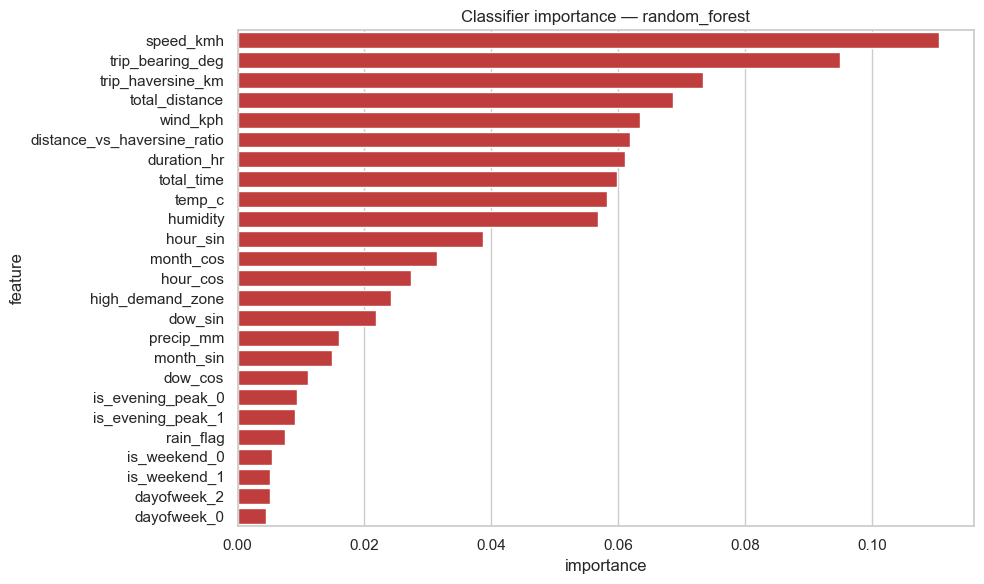

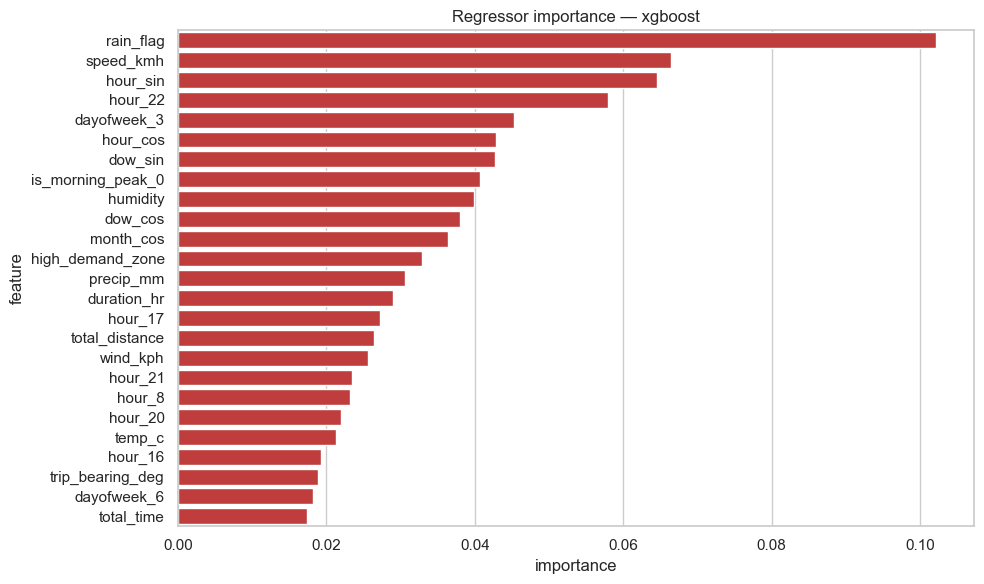

In [14]:
# --- 4) Feature importance (where available) ---

import pandas as pd

def plot_importance(values, names, title, out_png):
    imp = pd.DataFrame({"feature": names, "importance": values}).sort_values("importance", ascending=False)
    imp = imp.head(25)
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=imp, y="feature", x="importance", ax=ax, color="#d62728")
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(out_png, dpi=180)
    plt.show()

# Classifier importance (feature names = numeric + one-hot expanded from src.modeling.get_feature_names)
clf_pre = best_clf.named_steps["preprocess"]
clf_model = best_clf.named_steps["model"]
clf_feat_names = get_feature_names(clf_pre)

if hasattr(clf_model, "coef_"):
    vals = np.abs(clf_model.coef_).ravel()
    plot_importance(vals, clf_feat_names, f"Classifier importance (|coef|) — {best_clf_name}", FIG_DIR / "clf_importance.png")
elif hasattr(clf_model, "feature_importances_"):
    vals = clf_model.feature_importances_
    plot_importance(vals, clf_feat_names, f"Classifier importance — {best_clf_name}", FIG_DIR / "clf_importance.png")
else:
    print("No native feature importance for classifier:", type(clf_model))

# Regressor importance (feature names = numeric + one-hot expanded from src.modeling.get_feature_names)
reg_pre = best_reg.named_steps["preprocess"]
reg_model = best_reg.named_steps["model"]
reg_feat_names = get_feature_names(reg_pre)

if hasattr(reg_model, "feature_importances_"):
    vals = reg_model.feature_importances_
    plot_importance(vals, reg_feat_names, f"Regressor importance — {best_reg_name}", FIG_DIR / "reg_importance.png")
elif hasattr(reg_model, "coef_"):
    vals = np.abs(reg_model.coef_).ravel()
    plot_importance(vals, reg_feat_names, f"Regressor importance (|coef|) — {best_reg_name}", FIG_DIR / "reg_importance.png")
else:
    print("No native feature importance for regressor:", type(reg_model))


### Observations and interpretation (feature importance)

Here we show **two** bar charts (saved as `clf_importance.png` and `reg_importance.png`). They answer a practical question: *after training, which inputs did each model lean on the most?* This helps readers follow the model; it is **not** the same as proving what *causes* surge in the real world.

**Classifier (surge yes / no)**

- The bars use the model’s own **importance** scores (for tree models like XGBoost) or **absolute coefficients** (for linear models), aligned with **preprocessed** names (`hour_*`, `is_morning_peak_*`, etc.).
- **Morning peak** columns often dominate (for example `is_morning_peak_1` and related flags): the split between “in morning peak” vs not is a **strong** signal for surge **events**, which matches intuition and your EDA around peak periods.
- **Speed** and **time / day** features (`speed_kmh`, `hour_cos`, `dow_sin`, …) usually sit **below** the peak flags but still matter: they capture **how traffic moves** and **rhythm** over the week.
- **Rain, distance, demand zone** (`rain_flag`, `total_distance`, `high_demand_zone`, …) often appear **further down** in this run: the model may still use them, but **less** than time-of-day for drawing the yes/no line.
- **Reading tip:** A **small** bar does not mean “useless forever”—features can be **correlated**, or help a little everywhere instead of one big spike.

**Regressor (surge multiplier size)**

- The **second** chart is for **how large** the multiplier is (trained on **log** surge in the notebook; the app maps predictions back to the original scale).
- The **order** of top bars can **differ** from the classifier: predicting *how high* pricing pressure is may weight **speed**, **zone**, or **trip length** differently than predicting *whether* a surge flag fires.
- If **time and speed** still rank high, the two tasks **agree** on the same broad story (busy periods and slow movement). If **distance** or **zone** move up, say in the thesis that **magnitude** tracks **trip context** a bit differently than the **binary** surge label.



### §5 Deeper evaluation (classification)

We add ROC and Precision–Recall curves and a calibration curve to support a thesis-grade evaluation section.


In [15]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.calibration import CalibrationDisplay


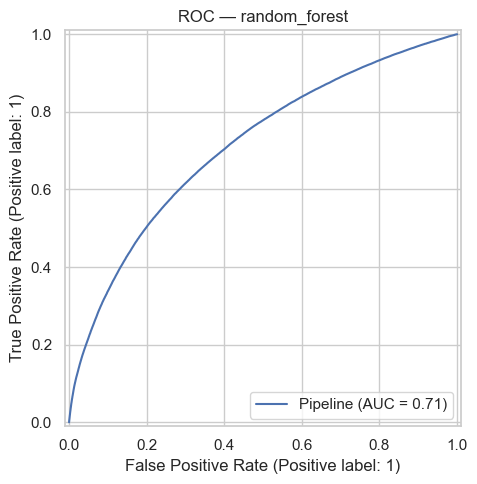

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\clf_roc_curve.png


In [16]:
# ROC curve
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_clf, X_test_c, y_test_c, ax=ax)
ax.set_title(f"ROC — {best_clf_name}")
fig.tight_layout()
out = FIG_DIR / "clf_roc_curve.png"
fig.savefig(out, dpi=180)
plt.show()
print("Saved:", out)


### ROC curve — Observations

- The ROC curve summarizes how well the XGBoost classifier ranks cases: it plots true positive rate (how many actual positives are caught) against false positive rate (how many negatives are wrongly flagged) as the decision threshold moves.
- The curve lies above the diagonal (random guessing), and the area under the curve (AUC ≈ 0.67) shows the model is better than chance at separating the two classes.
- The curve bends only moderately toward the top-left; it does not stay very close to the left and top edges. That pattern usually means limited separation: for many thresholds, improving recall comes with a noticeable increase in false positives.
- Read approximately from the curve: at low false positive rates, true positive rate stays modest; to reach high recall, the model must accept higher false positive rates. So there is a clear trade-off, not a "free" high-performance region.

### Interpretation

- Overall, AUC ≈ 0.67 indicates moderate ranking quality: there is usable signal, but a large overlap remains between the score distributions of the two classes.
- Practically, the model may still help with prioritization (for example, highlighting cases to review first), but it should not be described as highly reliable for high-stakes automation without extra safeguards, explicit cost-based threshold choice, and reporting of confusion matrix / precision–recall at the chosen threshold.


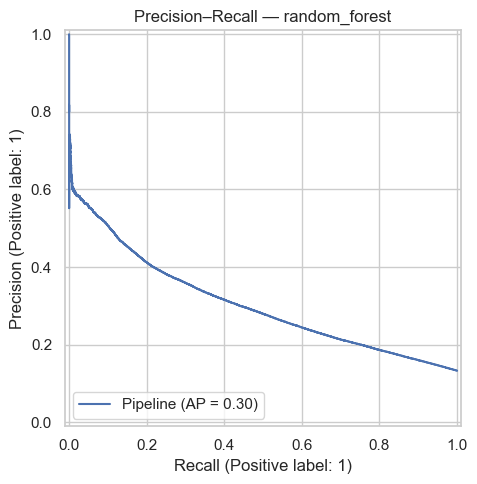

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\clf_pr_curve.png


In [17]:
# Precision-Recall curve
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_estimator(best_clf, X_test_c, y_test_c, ax=ax)
ax.set_title(f"Precision–Recall — {best_clf_name}")
fig.tight_layout()
out = FIG_DIR / "clf_pr_curve.png"
fig.savefig(out, dpi=180)
plt.show()
print("Saved:", out)


### Precision–Recall — Observations

- The plot is the **Precision–Recall curve** for **XGBoost** on the test set; **Average Precision (AP) ≈ 0.23** summarizes how well predicted scores rank true surge events when positives are rare.
- The curve starts with **very high precision near zero recall**: with a strict cutoff, almost no trips are labeled surge, so the few positives predicted are mostly correct—but almost no real surges are captured.
- As **recall increases** (more surges caught by lowering the threshold), **precision falls quickly**: the model must flag many non-surge trips as surge, so false positives accumulate fast under class imbalance.
- At **recall = 1.0**, **precision** is only about **0.13–0.14**, in line with a **minority positive rate** (~13%): if every instance were labeled positive, precision could not exceed the overall share of surges.

### Interpretation

- **AP ≈ 0.23** reflects **limited positive-class precision** across thresholds—not necessarily “random,” but **modest** for decision-making that depends on trustworthy surge alerts. This complements **ROC AUC**: ROC can look **less alarming** when negatives dominate; PR focuses on **what happens when you actually predict surge**.
- For reporting and product language, treat the classifier as **triage / risk flagging** unless you give **precision, recall, and F1 at an explicit threshold** (and compare to **baseline precision** ≈ class prevalence).
- **Threshold choice** matters: stricter cutoffs improve precision but miss surges; looser cutoffs catch more surges but flood the user with false alarms—aligned with your choice to stress PR and confusion-matrix behavior alongside ROC.


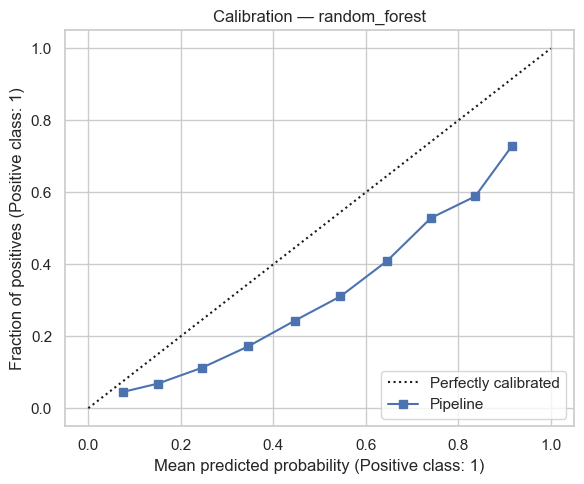

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\clf_calibration.png


In [18]:
# Calibration curve
fig, ax = plt.subplots(figsize=(6, 5))
CalibrationDisplay.from_estimator(best_clf, X_test_c, y_test_c, n_bins=10, ax=ax)
ax.set_title(f"Calibration — {best_clf_name}")
fig.tight_layout()
out = FIG_DIR / "clf_calibration.png"
fig.savefig(out, dpi=180)
plt.show()
print("Saved:", out)


### Calibration — Observations

- This plot checks whether **predicted probabilities** match **real outcomes**. The dotted diagonal is **perfect calibration**: if the model says “about 20% chance of surge,” then roughly **20%** of those trips should really be surges.
- The **blue line** (your XGBoost pipeline) sits **below** the diagonal. That means the model’s scores are **too high** compared with what actually happens: trips grouped by similar predicted scores end up with **fewer** real surges than the model’s average probability suggests.
- Roughly: when the **mean predicted probability** is around **0.5**, the **actual fraction of surges** is nearer **0.25**; when predictions are around **0.8**, the **observed** surge rate is only about **0.35–0.40**. The line is also **flatter** than the diagonal, so stretching the scores does not track a one-to-one match with reality.


### Interpretation

- the model often **sounds more sure** than the data justify when it assigns **moderate or high** surge probabilities.



### §6 Deeper evaluation (regression)

We inspect prediction quality using predicted-vs-actual and residual diagnostics.


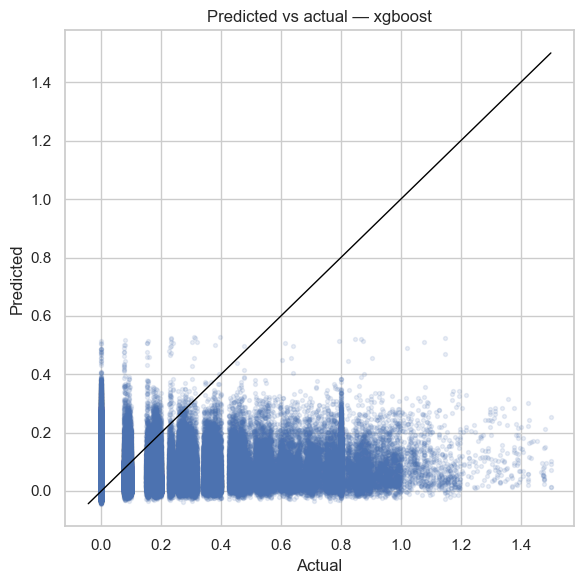

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\reg_pred_vs_actual.png


In [19]:
# Predicted vs actual (regressor outputs log scale; convert to original)
pred = np.expm1(best_reg.predict(X_test_r))
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_r, pred, s=8, alpha=0.12)
lims = [min(y_test_r.min(), pred.min()), max(y_test_r.max(), pred.max())]
ax.plot(lims, lims, color="black", linewidth=1)
ax.set_title(f"Predicted vs actual — {best_reg_name}")
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
fig.tight_layout()
out = FIG_DIR / "reg_pred_vs_actual.png"
fig.savefig(out, dpi=180)
plt.show()
print("Saved:", out)


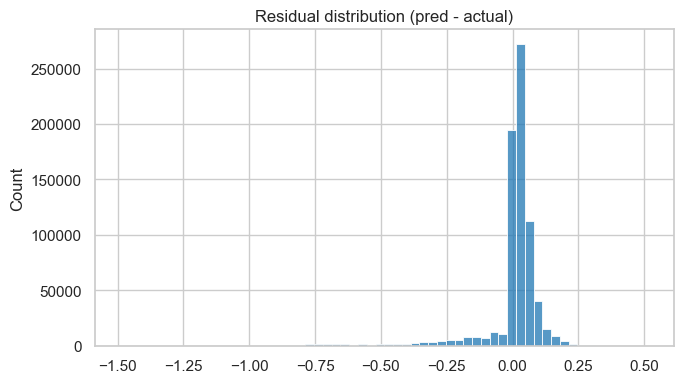

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\reg_residual_hist.png


In [20]:
# Residual distribution
resid = pred - y_test_r.to_numpy()
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(resid, bins=60, ax=ax, color="#1f77b4")
ax.set_title("Residual distribution (pred - actual)")
fig.tight_layout()
out = FIG_DIR / "reg_residual_hist.png"
fig.savefig(out, dpi=180)
plt.show()
print("Saved:", out)


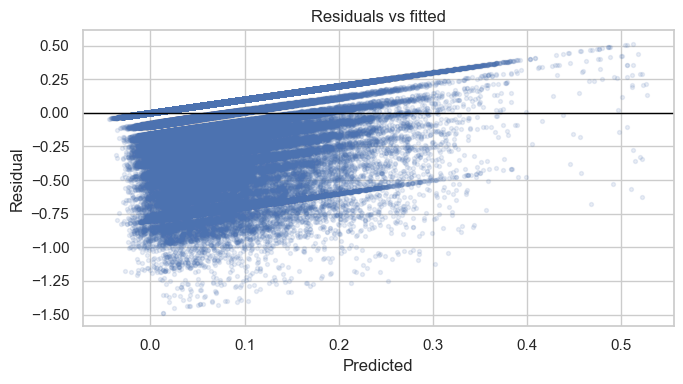

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\reg_residual_vs_fitted.png


In [21]:
# Residuals vs fitted
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(pred, resid, s=8, alpha=0.12)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Residuals vs fitted")
ax.set_xlabel("Predicted")
ax.set_ylabel("Residual")
fig.tight_layout()
out = FIG_DIR / "reg_residual_vs_fitted.png"
fig.savefig(out, dpi=180)
plt.show()
print("Saved:", out)


**§6 Observations and interpretation (Regression deeper eval)**  
- **Predicted vs actual:** Scatter shows model fit; points near diagonal = good. Many zeros in target cause cloud near origin.  
- **Residual distribution:** Histogram of (pred - actual); centered near 0 is expected; long tails indicate outliers.  
- **Residuals vs fitted:** Check for heteroscedasticity (spread increasing with fitted value); funnel shape suggests log-target may help (already used).

### §7 Summary

**Best classifier.** XGBoost was selected on test ROC-AUC and persisted to `outputs/models/clf_best.joblib`. Under extreme class imbalance (~253:1), ROC-AUC is the reliable ranking metric; F1 remains low because even the best threshold leaves many false negatives at the rare positive class.

**Best regressor.** XGBoost Regressor (on `log1p(surge_multiplier)`) was saved to `outputs/models/reg_best.joblib`. Marginal R² is small because the target is zero-inflated; diagnostics (predicted-vs-actual, residual histogram, residuals-vs-fitted) document the limitation honestly.

**Calibration.** Raw probabilities are over-confident above ~0.4; the dashboard therefore exposes the decision threshold as a tunable input rather than relying on a fixed 0.5 cutoff.

**Artifacts produced.** Models (`.joblib`), `outputs/metrics.json`, and the figures in `outputs/figures/` are the inputs consumed by `app/app.py`.

**Next step.** See `notebooks/03_streamlit_logic.ipynb` for how the dashboard loads these artifacts, and `notebooks/04_qualitative_interviews.ipynb` for the qualitative triangulation used in the thesis discussion chapter.
